# STEP 4 — mAb-GATED 모델 학습 (재현용)

`step3_edges.csv`(또는 공개 엣지 데이터)로 **mAb-GATED** 를 학습합니다. 그래프에서 안정성 노드를 가리고 이웃으로 맞히는 '빈칸 채우기' 모델이에요.

| | |
|---|---|
| **입력** | `step3_edges.csv` (없으면 공개 엣지 자동 다운로드) |
| **출력** | 학습된 모델 `mab_gated.pt`, 결과 `results.json` |
| **필요** | **GPU 런타임** (Colab 메뉴: 런타임 → 런타임 유형 변경 → T4 GPU) · OpenAI 키 불필요 |

> 🔧 원본 연구 노트북을 **그대로** 쓰되, 사설 DB 접속 부분만 CSV 로딩으로 바꿨습니다(모델 코드는 동일).
> ⚠️ 소규모 데이터면 성능 수치는 논문과 다릅니다. 공개 엣지(2,436개)로 돌리면 의미 있는 결과를 볼 수 있어요.

# mAb-GATED
## Masked Stability Node Prediction on mAb Directed Association Network

**Task:** Predict a masked canonical stability node from its neighborhood context  
**Data:** `step2c_v4d_normalized_edges.csv` (frequency ≥ 1)

---
### Input Structure per Sample
```
TARGET : one canonical stability node  (e.g., aggregation)
INPUT  : 6 domain categories × K neighbors each
         ├── Direct   (1-hop): cause → target
         └── Indirect (2-hop): grandcause → cause → target
         Pool entries are repeated by frequency so that
         frequently-reported associations are sampled more often.
```
### Architecture
```
Encoded input tokens [B, 6*K, 4]
       ↓  Embedding  (node + category + relation + direction → d-dim)
       ↓  GAT        (graph-structure signal via global edge index)
       ↓  Transformer Encoder  (bidirectional self-attention)
       ↓  Mean Pooling         (context vector)
       ↓  Transformer Decoder  (generate masked node)
       ↓  Constrained Output   (physical / chemical / biological pool)
```

## STEP 0. Environment Setup

In [ ]:
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q',
                'sentence-transformers'], check=False)

import random, os, copy, json, warnings, shutil
from collections import defaultdict, Counter

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sentence_transformers import SentenceTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics.pairwise import cosine_similarity as cos_sim

warnings.filterwarnings('ignore')


def select_gpu():
    """Select the GPU with the most free memory; fall back to CPU."""
    if not torch.cuda.is_available():
        print('CUDA not available — using CPU')
        return torch.device('cpu')
    try:
        r = subprocess.run(
            ['nvidia-smi', '--query-gpu=index,memory.free',
             '--format=csv,noheader,nounits'],
            capture_output=True, text=True)
        gpus = [(int(l.split(',')[0].strip()), int(l.split(',')[1].strip()))
                for l in r.stdout.strip().split('\n')]
        best = max(gpus, key=lambda x: x[1])
        print(f'Selected GPU {best[0]} ({best[1]} MB free)')
        return torch.device(f'cuda:{best[0]}')
    except Exception:
        return torch.device('cuda:0')


def seed_everything(seed: int = 42):
    """Fix all random seeds for reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


device = select_gpu()
SEED   = 42
seed_everything(SEED)
print(f'Device  : {device}')
print(f'PyTorch : {torch.__version__}')

Selected GPU 0 (12576 MB free)
Device  : cuda:0
PyTorch : 2.10.0+cu128


In [ ]:
import os
# (재현용) Google Drive 마운트·사설 DB 제거 → 로컬 폴더 사용
LOCAL_DIR  = './'
RESULT_DIR = './gated_out/'
os.makedirs(RESULT_DIR, exist_ok=True)

CONFIG = {
    'result_dir':   RESULT_DIR,
    'local_dir':    LOCAL_DIR,
    'edges_csv':    'step3_edges.csv',                 # STEP 3 출력
    'sample_url':   'https://raw.githubusercontent.com/STARG-LEE/mab-causal-network-v2/main/step2c_v4d_causal_edges_summary.csv',  # 없으면 공개 엣지

    'min_freq':     1,
    'K':            5,
    'bert_model':   'pritamdeka/S-PubMedBert-MS-MARCO',
    'bert_dim':     768,
    'bert_batch':   64,

    'hidden_dim':   128, 'nhead': 4, 'enc_layers': 2, 'dec_layers': 2,
    'dropout': 0.2, 'gat_heads': 4, 'gat_layers': 2,

    'lr': 0.001, 'epochs': 500, 'patience': 50, 'batch_size': 64, 'label_smooth': 0.1,

    'distmult_dim': 128, 'distmult_epochs': 500, 'distmult_neg': 50, 'distmult_margin': 3.0,
}

CAT_ORDER = ['formulation', 'stress', 'stability', 'quality_outcome', 'structure', 'sequence']
K = CONFIG['K']
print('재현용 설정 로드 — 사설 DB/드라이브 없이 CSV로 동작')
print(f'K = {K} neighbors/category')

Mounted at /content/drive
MIN_FREQ = 1
K        = 5 neighbors per category per sample


## STEP 1. Canonical Grouping & Sub-category Definitions

In [ ]:
# CANONICAL_MAP: variant node name → canonical representative.
# Merging semantically equivalent variants concentrates frequency signal
# and reduces the prediction candidate pool.
CANONICAL_MAP = {
    # Physical
    'aggregate amount':'aggregation','aggregation and particle formation':'aggregation',
    'aggregation kinetics':'aggregation','aggregation propensity':'aggregation',
    'aggregation rate':'aggregation','aggregation rates':'aggregation',
    'increased aggregation':'aggregation','storage-induced aggregation':'aggregation',
    'aggregate growth':'aggregation','aggregate formation':'aggregation',
    'aggregation stability':'aggregation','soluble aggregates':'aggregation',
    'insoluble aggregates':'aggregation','surface-induced aggregation':'aggregation',
    'process-induced aggregation':'aggregation','low ph aggregation':'aggregation',
    'colloidal aggregation':'aggregation','interfacial aggregation':'aggregation',
    'pre-aggregates':'aggregation','reduced aggregation':'aggregation',
    'increased viscosity':'viscosity','formulation viscosity':'viscosity',
    'concentration-dependent viscosity':'viscosity','solution viscosity':'viscosity',
    'decreased viscosity':'viscosity',
    'particle size':'particle formation','particle concentration':'particle formation',
    'particle metrics':'particle formation','particle aggregation':'particle formation',
    'subvisible particles':'particle formation',
    'increased particle formation':'particle formation',
    'ffa particle formation':'particle formation',
    'particle size distribution':'particle formation',
    'bulk particle formation':'particle formation',
    'colloidal instability':'colloidal stability',
    'decreased colloidal stability':'colloidal stability',
    'reversible self-association':'self-association',
    'non-covalent dimerization':'self-association',
    'dimerization':'self-association','oligomer formation':'self-association',
    'oligomerization':'self-association','multimerization':'self-association',
    'self-association propensity':'self-association',
    'reversible oligomerization':'self-association',
    'precipitation':'solubility','decreased solubility':'solubility',
    'increased solubility':'solubility','reduced solubility':'solubility',
    'liquid-liquid phase separation':'solubility','phase separation':'solubility',
    'increased hmw species':'hmw species','hmw species formation':'hmw species',
    'oxidative hmw species':'hmw species',
    'monomer stability':'monomer content','decreased monomer':'monomer content',
    'monomer purity':'monomer content','monomer percentage':'monomer content',
    'monomer recovery':'monomer content','monomer yield':'monomer content',
    'residual monomer':'monomer content','decreased monomer content':'monomer content',
    'monomer loss':'monomer content',
    'diffusion coefficient':'diffusion interaction parameter',
    'second virial coefficient':'diffusion interaction parameter',
    'surface adsorption':'adsorption',
    'adsorption to silicone oil-water interface':'adsorption',
    'adsorption to interfaces':'adsorption','prevention of adsorption':'adsorption',
    'adsorption to hydrophobic surfaces':'adsorption',
    'adsorption to air-water interface':'adsorption',
    'interfacial adsorption':'adsorption','silicone oil migration':'adsorption',
    'surface rheology':'interfacial stability',
    'interfacial viscoelasticity':'interfacial stability',
    'interfacial rheology':'interfacial stability',
    'interfacial elasticity':'interfacial stability',
    'opalescence':'turbidity',
    # Chemical
    'methionine oxidation':'oxidation','tryptophan oxidation':'oxidation',
    'amino acid oxidation':'oxidation','heavy chain oxidation':'oxidation',
    'oxidation susceptibility':'oxidation','photooxidation':'oxidation',
    'photochemical oxidation':'oxidation','oxidative degradation':'oxidation',
    'protein photodegradation':'oxidation','met1 oxidation':'oxidation',
    'histidine oxidation':'oxidation','tyrosine oxidation':'oxidation',
    'subunit oxidation':'oxidation',
    'asparagine deamidation':'deamidation','deamidation rate':'deamidation',
    'site-specific deamidation':'deamidation','asn55 deamidation':'deamidation',
    'isoaspartate formation':'deamidation','succinimide formation':'deamidation',
    'succinimide ring closure':'deamidation','succinimide':'deamidation',
    'pyroglutamate formation':'deamidation',
    'protein fragments':'fragmentation','site-specific fragmentation':'fragmentation',
    'fragmentation rate':'fragmentation','antibody fragment':'fragmentation',
    'proteolysis':'fragmentation','proteolytic degradation':'fragmentation',
    'hc c-terminal clipping':'fragmentation','n-terminal clipping':'fragmentation',
    'backbone cleavage':'fragmentation',
    'polysorbate degradation':'degradation','lysosomal degradation':'degradation',
    'degradation products':'degradation','degradation rate':'degradation',
    'heat-induced degradation':'degradation','storage degradation':'degradation',
    'mab degradation':'degradation','degradation pathways':'degradation',
    'chemical degradation':'degradation','enzymatic degradation':'degradation',
    'n-glycan degradation':'degradation','polysorbate hydrolysis':'degradation',
    'surfactant degradation':'degradation','hydrolytic stability':'degradation',
    'product degradation':'degradation','photodegradation':'degradation',
    'asp isomerization':'isomerization','aspartate isomerization':'isomerization',
    'charge heterogeneity':'charge variants','acidic variants':'charge variants',
    'charge variant distribution':'charge variants',
    'charge variant separation':'charge variants',
    'acidic charge variant':'charge variants',
    'site-specific lysine glycation':'glycation','lysine glycation':'glycation',
    'disulfide reduction':'disulfide','disulfide scrambling':'disulfide',
    'disulfide bond stability':'disulfide','disulfide stability':'disulfide',
    'disulfide exchange':'disulfide','disulfide heterogeneity':'disulfide',
    'physicochemical stability':'physicochemical properties',
    'chemical stability':'physicochemical properties',
    'physical modification':'physicochemical properties',
    'post-translational modifications':'physicochemical properties',
    'modification':'physicochemical properties',
    'chemical modification':'physicochemical properties',
    # Biological
    'conformational change':'conformational stability',
    'conformational changes':'conformational stability',
    'conformational instability':'conformational stability',
    'conformational dynamics':'conformational stability',
    'conformational transitions':'conformational stability',
    'higher-order structure':'conformational stability',
    'structural integrity':'conformational stability',
    'protein integrity':'conformational stability',
    'secondary structure retention':'conformational stability',
    'ch2 thermal stability':'thermal stability',
    'ch2 domain stability':'thermal stability',
    'thermal denaturation':'thermal stability','denaturation':'thermal stability',
    'decreased thermal stability':'thermal stability',
    'thermodynamic stability':'thermal stability',
    'irreversible denaturation':'thermal stability',
    'increased thermal stability':'thermal stability',
    'thermal unfolding':'thermal stability',
    'ch2 melting temperature':'melting temperature',
    'ch3 melting temperature':'melting temperature',
    'domain melting temperature':'melting temperature',
    'second unfolding transition':'melting temperature',
    'partial unfolding':'protein unfolding','domain unfolding':'protein unfolding',
    'protein misfolding':'protein unfolding',
    'formulation stability':'storage stability','in vitro stability':'storage stability',
    'solution stability':'storage stability','accelerated stability':'storage stability',
    'lyophilized stability':'storage stability',
    'drug product stability':'storage stability',
    'freeze-thaw stability':'storage stability','dry-state stability':'storage stability',
    'solid-state stability':'storage stability',
    'spray-drying stability':'storage stability',
    'room temperature stability':'storage stability',
    'liquid formulation stability':'storage stability',
    'high-concentration stability':'storage stability',
    'serum stability':'in vivo stability','plasma stability':'in vivo stability',
    'circulatory stability':'in vivo stability',
    'metabolic stability':'in vivo stability',
    'increased serum stability':'in vivo stability',
    'pharmacokinetic stability':'in vivo stability',
    'blood stability':'in vivo stability',
    'functional stability':'bioactivity','biological activity':'bioactivity',
    'binding activity':'bioactivity','binding affinity':'bioactivity',
    'efficacy stability':'bioactivity',
    'in vivo half-life':'half-life','serum half-life':'half-life',
    'circulating half-life':'half-life','clearance':'half-life',
    'payload clearance':'half-life',
    'protein stability':'stability (general)',
    'increased stability':'stability (general)',
    'decreased stability':'stability (general)',
    'physical stability':'stability (general)',
    'instability':'stability (general)',
    'drug stability':'stability (general)',
    'antibody stability':'stability (general)',
    'microbial growth':'microbiological stability',
    'conjugate stability':'linker stability','chelate stability':'linker stability',
}

# Prediction target sets (canonical node names only)
PHYSICAL_NODES = {
    'aggregation','viscosity','particle formation','colloidal stability',
    'self-association','solubility','hmw species','monomer content',
    'diffusion interaction parameter','adsorption','interfacial stability','turbidity',
}
CHEMICAL_NODES = {
    'oxidation','deamidation','fragmentation','degradation','isomerization',
    'charge variants','glycation','disulfide','physicochemical properties',
}
BIOLOGICAL_NODES = {
    'conformational stability','thermal stability','melting temperature',
    'protein unfolding','storage stability','in vivo stability','bioactivity',
    'half-life','immunogenicity','microbiological stability','linker stability',
    'biophysical properties','stability (general)',
}

# Nodes excluded from prediction targets.
# 'stability' itself is excluded (too generic — the category name).
# These nodes remain in the graph as neighborhood context (input) only.
EXCLUDE_FROM_PREDICTION = {
    'stability','b7-h3 expression','cytokine release','salmonella typhi',
    'ovalbumin','russell bodies','rdh5 level','zinc','al amyloidosis',
    'hemagglutination','tau aggregation','tau oligomers','tau fibril maturation',
    'alpha-synuclein propagation','aβ42 fibrillogenesis','amyloid fibril formation',
    'amyloid-beta deposition','amyloid beta degradation','amyloid beta fibrillation',
    'fibril formation','resin discoloration','positive signal','siga2 degradation',
    'siga2 stability','rnase activity','strip stability','probe stability',
    'expression stability','cell line stability','biotransformation',
    'proteasomal degradation','protein assembly','sustained release',
    'payload release','drug release','premature payload release',
    'intracellular payload release','tumor release efficiency','film formation',
    'film strength','reconstitution time','polysorbate stability','product quality',
    'nucleation rate','crystallization','stability prediction',
    'dynamic binding capacity','bubble formation','gelation',
    'gastrointestinal stability','antigenicity','immune complex formation',
    'production stability','process stability','fusion instability','fusion stability',
    'liposome stability','radiochemical purity','assay stability',
    'membrane permeability','surfactant hydrolysis','polysorbate oxidation',
    'polysorbate 20 degradation','glutamate esterification',
    'trehalose recrystallization','molecular stability','stabilization',
    'electrostatic interactions','non-specific interactions','interactions',
    'functionality','product content','payload loss','drug loss',
    'peg properties','payload degradation',
}

SUBCAT_ORDER = ['physical', 'chemical', 'biological']
subcat2id    = {s: i+1 for i, s in enumerate(SUBCAT_ORDER)}
id2subcat    = {i: s for s, i in subcat2id.items()}

def get_canonical(node): return CANONICAL_MAP.get(node, node)

def get_subcat(canonical_node):
    if canonical_node in PHYSICAL_NODES:   return 'physical'
    if canonical_node in CHEMICAL_NODES:   return 'chemical'
    if canonical_node in BIOLOGICAL_NODES: return 'biological'
    return 'unknown'

print(f'Canonical map     : {len(CANONICAL_MAP)} entries')
print(f'Physical targets  : {len(PHYSICAL_NODES)}')
print(f'Chemical targets  : {len(CHEMICAL_NODES)}')
print(f'Biological targets: {len(BIOLOGICAL_NODES)}')
print(f'Excluded nodes    : {len(EXCLUDE_FROM_PREDICTION)}')

Canonical map     : 210 entries
Physical targets  : 12
Chemical targets  : 9
Biological targets: 13
Excluded nodes    : 76


## STEP 2. Data Loading & Frequency Replication

In [ ]:
# (재현용) 사설 DB 대신 CSV 로드
import os, pandas as pd
if os.path.exists(CONFIG['edges_csv']):
    df_raw = pd.read_csv(CONFIG['edges_csv']); print('STEP 3 결과 사용:', CONFIG['edges_csv'])
else:
    df_raw = pd.read_csv(CONFIG['sample_url']); print('공개 엣지 데이터 사용 (STEP 3 결과 없음)')

# 컬럼 표준화: cause_std/effect_std → cause/effect (있을 때만)
df_raw = df_raw.rename(columns={'cause_std': 'cause', 'effect_std': 'effect'})
df = df_raw[df_raw['frequency'] >= CONFIG['min_freq']].copy().reset_index(drop=True)
print(f'엣지 {len(df_raw):,} → {len(df):,} (frequency >= {CONFIG["min_freq"]})')
print('Columns:', list(df.columns))

# 빈도만큼 행 복제 (원본과 동일: 자주 보고된 관계가 더 자주 샘플링됨)
df_rep = df.loc[df.index.repeat(df['frequency'])].copy().reset_index(drop=True)
print(f'복제 후 행: {len(df_rep):,}')
print(df_rep['category_effect'].value_counts().to_string())

Raw edges      : 32,939
Filtered edges : 32,939  (frequency >= 1)
Columns        : ['id', 'cause', 'category_cause', 'effect', 'category_effect', 'relationship', 'frequency', 'num_papers', 'main_confidence', 'sample_evidence', 'pmid_list', 'created_at']

Replicated rows: 39,792

Replicated rows by category_effect:
category_effect
quality_outcome    18931
stability          12702
structure           4744
sequence            1665
formulation         1122
stress               627
neutral                1


## STEP 3. Stability Dataset Construction

In [ ]:
# Extract rows where the effect is a stability node.
# df_rep is used so that high-frequency associations appear more often,
# giving the model proportionally more training signal for them.
df_stab = df_rep[df_rep['category_effect'] == 'stability'].copy().reset_index(drop=True)

print(f'df_stab rows        : {len(df_stab):,}')
print(f'Unique effect nodes : {df_stab["effect"].nunique()}')

# Apply canonical mapping and sub-category assignment
df_stab['effect_canonical'] = df_stab['effect'].map(get_canonical)
df_stab['subcat']           = df_stab['effect_canonical'].map(get_subcat)

# Remove excluded nodes and nodes with unknown sub-category.
# Excluded nodes are kept in the graph for neighborhood context (input)
# but are never used as prediction targets (output).
df_stab_filtered = df_stab[
    ~df_stab['effect_canonical'].isin(EXCLUDE_FROM_PREDICTION) &
    (df_stab['subcat'] != 'unknown')
].copy().reset_index(drop=True)

print(f'\nBefore filter : {len(df_stab):,} rows')
print(f'After  filter : {len(df_stab_filtered):,} rows')
print()
print('Sub-category distribution:')
print(df_stab_filtered.groupby('subcat')['effect_canonical']
      .agg(samples='count', unique_nodes='nunique').to_string())
print()
print('Top 20 canonical nodes by sample count:')
top20 = (df_stab_filtered.groupby(['subcat','effect_canonical'])
         .size().reset_index(name='count')
         .sort_values('count', ascending=False).head(20))
print(top20.to_string(index=False))

df_stab rows        : 12,702
Unique effect nodes : 2289

Before filter : 12,702 rows
After  filter : 8,201 rows

Sub-category distribution:
            samples  unique_nodes
subcat                           
biological     2343            11
chemical       1884             9
physical       3974            12

Top 20 canonical nodes by sample count:
    subcat           effect_canonical  count
  physical                aggregation   1974
  physical                  viscosity    568
  chemical              fragmentation    515
biological                  half-life    511
  chemical                degradation    501
  physical           self-association    397
  physical                 solubility    377
biological        stability (general)    345
  chemical                  oxidation    324
biological   conformational stability    315
biological          thermal stability    270
biological                bioactivity    268
biological          storage stability    218
biological         

In [ ]:
# Build a frequency-weighted neighbor pool for each canonical stability node.
# Pool includes both direct (1-hop) and indirect (2-hop) causes.
# Pool construction uses df (original edges, not replicated) to avoid
# double-counting; frequency is used explicitly as a repeat count.

def build_cat_pool(target_node: str) -> dict:
    """
    Collect all 1-hop and 2-hop causes for target_node by category.

    Each cause entry is repeated by its edge frequency so that
    frequently-reported associations dominate random sampling.

    1-hop: cause → target_node  (direct)
    2-hop: grandcause → cause → target_node  (indirect)
    """
    cat_pool = {cat: [] for cat in CAT_ORDER}
    df_1hop  = df[df['effect'] == target_node].copy()

    for _, row in df_1hop.iterrows():
        entry = {'node': row['cause'], 'rel': row['relationship'], 'hop': 1}
        cat_pool[row['category_cause']].extend([entry] * row['frequency'])

    for cause_1hop in df_1hop['cause'].unique():
        df_2hop = df[df['effect'] == cause_1hop].copy()
        for _, row in df_2hop.iterrows():
            entry = {'node': row['cause'], 'rel': row['relationship'], 'hop': 2}
            cat_pool[row['category_cause']].extend([entry] * row['frequency'])

    return cat_pool


def sample_from_pool(pool: list, k: int, use_random: bool = True) -> list:
    """
    Select k nodes from a frequency-weighted pool.

    use_random=True  : frequency-proportional weighted sampling (training)
    use_random=False : top-k by frequency (validation / test)
    """
    if not pool:
        return []
    freq_map = {}
    for e in pool:
        n = e['node']
        if n not in freq_map:
            freq_map[n] = {'node': e['node'], 'rel': e['rel'],
                           'hop': e['hop'], 'freq': 0}
        freq_map[n]['freq'] += 1
    unique = list(freq_map.values())
    if use_random:
        weights  = [u['freq'] for u in unique]
        k_actual = min(k, len(unique))
        chosen   = random.choices(unique, weights=weights, k=k_actual)
        seen, result = set(), []
        for c in chosen:
            if c['node'] not in seen:
                seen.add(c['node'])
                result.append(c)
        return result
    else:
        return sorted(unique, key=lambda x: -x['freq'])[:k]


# Pre-build pool cache for all canonical stability nodes
print('Building pool cache (1-hop + 2-hop) ...')
pool_cache      = {}
canonical_nodes = df_stab_filtered['effect_canonical'].unique().tolist()
for node in canonical_nodes:
    pool_cache[node] = build_cat_pool(node)
print(f'Done. {len(pool_cache)} canonical nodes cached.')
print()
print('Top 5 nodes by pool size:')
pool_sizes = {n: sum(len(pool_cache[n][c]) for c in CAT_ORDER)
              for n in canonical_nodes}
for n, sz in sorted(pool_sizes.items(), key=lambda x: -x[1])[:5]:
    print(f'  {n:45s}  pool={sz:,}')

Building pool cache (1-hop + 2-hop) ...
Done. 32 canonical nodes cached.

Top 5 nodes by pool size:
  immunogenicity                                 pool=17,134
  aggregation                                    pool=16,492
  degradation                                    pool=12,893
  half-life                                      pool=11,164
  conformational stability                       pool=9,820


In [ ]:
# Train / Validation / Test split (row-level).
# Each row in df_stab_filtered is an independent training sample.
# The same canonical target node appears multiple times with different
# cause contexts — this is intentional and reflects the frequency weighting.
seed_everything(SEED)

train_df, temp_df = train_test_split(df_stab_filtered, test_size=0.3, random_state=SEED)
valid_df, test_df = train_test_split(temp_df,           test_size=0.5, random_state=SEED)

train_df = train_df.reset_index(drop=True)
valid_df = valid_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print(f'Total : {len(df_stab_filtered):,}')
print(f'Train : {len(train_df):,}  (70%)')
print(f'Valid : {len(valid_df):,}  (15%)')
print(f'Test  : {len(test_df):,}  (15%)')
print()
for split_name, split_df in [('Train', train_df), ('Valid', valid_df), ('Test', test_df)]:
    counts = split_df.groupby('subcat')['effect_canonical'].agg(
        samples='count', unique_nodes='nunique')
    print(f'[{split_name}]')
    print(counts.to_string()); print()


def make_dataset(df_source: pd.DataFrame,
                 use_random: bool = True,
                 k: int = K) -> list:
    """
    Build a list of samples from df_source.

    Each row → one sample with target=effect_canonical and
    input built by sampling k neighbors per category from pool_cache.

    use_random=True  : random weighted sampling (training diversity)
    use_random=False : deterministic top-k (reproducible val/test)
    """
    samples = []
    for _, row in df_source.iterrows():
        target = row['effect_canonical']
        if target not in pool_cache:
            continue
        sample = {'target': target, 'subcat': row['subcat'], 'input': {}}
        for cat in CAT_ORDER:
            sample['input'][cat] = sample_from_pool(
                pool_cache[target][cat], k=k, use_random=use_random)
        samples.append(sample)
    return samples


train_samples = make_dataset(train_df, use_random=True)
valid_samples = make_dataset(valid_df, use_random=False)
test_samples  = make_dataset(test_df,  use_random=False)

print(f'Train samples : {len(train_samples):,}')
print(f'Valid samples : {len(valid_samples):,}')
print(f'Test  samples : {len(test_samples):,}')
print()

# Inspect one sample
s = train_samples[0]
print(f'TARGET : {s["target"]}  [{s["subcat"]}]')
for cat in CAT_ORDER:
    nodes = s['input'][cat]
    print(f'  [{cat}]  {len(nodes)} neighbors')
    for n in nodes:
        hop = 'direct' if n['hop']==1 else 'indirect'
        print(f'    ({hop}) {n["node"]:40s}  --{n["rel"]}-->')

Total : 8,201
Train : 5,740  (70%)
Valid : 1,230  (15%)
Test  : 1,231  (15%)

[Train]
            samples  unique_nodes
subcat                           
biological     1683            11
chemical       1295             9
physical       2762            12

[Valid]
            samples  unique_nodes
subcat                           
biological      333            10
chemical        297             9
physical        600            12

[Test]
            samples  unique_nodes
subcat                           
biological      327             9
chemical        292             8
physical        612            11

Train samples : 5,740
Valid samples : 1,230
Test  samples : 1,231

TARGET : bioactivity  [biological]
  [formulation]  0 neighbors
  [stress]  0 neighbors
  [stability]  0 neighbors
  [quality_outcome]  0 neighbors
  [structure]  0 neighbors
  [sequence]  0 neighbors


## STEP 4. Integer Encoding

In [ ]:
# Collect all unique nodes and relations from the full dataset
all_nodes_set = set()
all_rels_set  = set()
for split in [train_samples, valid_samples, test_samples]:
    for s in split:
        all_nodes_set.add(s['target'])
        for cat in CAT_ORDER:
            for e in s['input'][cat]:
                all_nodes_set.add(e['node'])
                all_rels_set.add(e['rel'])

# 1-indexed encoding (0 = PAD, permanently reserved)
all_nodes_list = sorted(all_nodes_set)
all_rels_list  = sorted(all_rels_set)

node2id = {n: i+1 for i, n in enumerate(all_nodes_list)}
id2node = {i: n for n, i in node2id.items()}
rel2id  = {r: i+1 for i, r in enumerate(all_rels_list)}
id2rel  = {i: r for r, i in rel2id.items()}

num_nodes = len(all_nodes_list)
num_rels  = len(all_rels_list)
num_cats  = len(CAT_ORDER)

# Direction encoding: 1=direct(1-hop), 2=indirect(2-hop), 0=PAD
DIR_PAD, DIR_DIRECT, DIR_INDIRECT = 0, 1, 2
num_dirs = 3

# Candidate pools per sub-category (node IDs) for constrained decoding
subcat_node_ids = defaultdict(list)
for node in canonical_nodes:
    sc = get_subcat(node)
    if sc in subcat2id and node in node2id:
        subcat_node_ids[sc].append(node2id[node])

print(f'Unique nodes : {num_nodes}  (IDs 1~{num_nodes}, 0=PAD)')
print(f'Unique rels  : {num_rels}')
print()
print('Candidate pool sizes per sub-category:')
for sc in SUBCAT_ORDER:
    ps = len(subcat_node_ids[sc])
    if ps == 0: continue
    rand_mrr = sum(1/k for k in range(1, ps+1)) / ps
    print(f'  {sc:12s}: {ps:4d} nodes  '
          f'random MRR≈{rand_mrr:.3f}  '
          f'random H@1={1/ps*100:.1f}%')

Unique nodes : 8670  (IDs 1~8670, 0=PAD)
Unique rels  : 39

Candidate pool sizes per sub-category:
  physical    :   12 nodes  random MRR≈0.259  random H@1=8.3%
  chemical    :    9 nodes  random MRR≈0.314  random H@1=11.1%
  biological  :   11 nodes  random MRR≈0.275  random H@1=9.1%


## STEP 5. PubMedBERT Node Initialization

## 🔤 단어에 '의미'를 입히기 (PubMedBERT)

컴퓨터는 'sucrose'와 'trehalose'가 비슷한 당류라는 걸 모릅니다. 그래서 **PubMedBERT**(의학 논문으로 학습된 언어모델)로 각 노드 이름을 **768개 숫자(벡터)** 로 바꿔요. 뜻이 비슷한 단어는 숫자도 비슷해집니다.

> 🧩 비유: **외국어 사전**. 백지에서 배우지 않고 *이미 뜻을 아는 사전*을 주고 시작 → 학습이 빠르고 똑똑해집니다.
> 아래 유사도 출력에서 `sucrose ↔ trehalose` 점수가 높게 나오면 성공!

In [ ]:
# Encode each node name as a 768-dim biomedical semantic vector.
# PubMedBERT is used ONLY to initialize node_emb weights before training.
# During training, node_emb is updated normally via backpropagation.
# PubMedBERT itself is never updated.
print(f'Loading: {CONFIG["bert_model"]} ...')
bert_encoder = SentenceTransformer(CONFIG['bert_model'])
bert_encoder.eval()

print(f'Encoding {num_nodes} node names ...')
node_bert_emb = bert_encoder.encode(
    all_nodes_list,
    batch_size=CONFIG['bert_batch'],
    show_progress_bar=True,
    convert_to_numpy=True)   # [num_nodes, 768]
print(f'Done. Shape: {node_bert_emb.shape}')

# Sanity check
check_pairs = [
    ('sucrose', 'trehalose'),
    ('sucrose', 'aggregation'),
    ('oxidation', 'deamidation'),
    ('conformational stability', 'thermal stability'),
    ('aggregation', 'viscosity'),
]
print('\nCosine similarity check (PubMedBERT):')
for n1, n2 in check_pairs:
    if n1 in node2id and n2 in node2id:
        sim = cos_sim(node_bert_emb[[node2id[n1]-1]],
                      node_bert_emb[[node2id[n2]-1]])[0, 0]
        print(f'  {n1:40s} <-> {n2:35s}  {sim:.4f}')

Loading: pritamdeka/S-PubMedBert-MS-MARCO ...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: pritamdeka/S-PubMedBert-MS-MARCO
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Encoding 8670 node names ...


Batches:   0%|          | 0/136 [00:00<?, ?it/s]

Done. Shape: (8670, 768)

Cosine similarity check (PubMedBERT):
  sucrose                                  <-> trehalose                            0.8970
  sucrose                                  <-> aggregation                          0.8219
  oxidation                                <-> deamidation                          0.8499
  conformational stability                 <-> thermal stability                    0.9142
  aggregation                              <-> viscosity                            0.8306


In [ ]:
# Project 768-dim → hidden_dim via a learned linear layer.
# This projection is part of the model and is updated during training.
# PubMedBERT vectors are computed once here and reused only for initialization.
bert_proj = nn.Linear(CONFIG['bert_dim'], CONFIG['hidden_dim'], bias=False).to(device)
nn.init.xavier_uniform_(bert_proj.weight)

with torch.no_grad():
    bert_tensor = torch.tensor(node_bert_emb, dtype=torch.float32).to(device)
    node_init   = bert_proj(bert_tensor).cpu()   # [num_nodes, hidden_dim]

print(f'PubMedBERT projection: {CONFIG["bert_dim"]}d → {CONFIG["hidden_dim"]}d')
print(f'node_init shape: {node_init.shape}')
print('These values will initialize node_emb in mAb-GATED.')
print('After initialization, node_emb is trained normally via backpropagation.')

PubMedBERT projection: 768d → 128d
node_init shape: torch.Size([8670, 128])
These values will initialize node_emb in mAb-GATED.
After initialization, node_emb is trained normally via backpropagation.


## STEP 6. PyTorch Dataset & DataLoader

In [ ]:
def encode_sample(sample: dict, k: int = K) -> torch.Tensor:
    """
    Convert one sample dict into a fixed-size integer tensor [6*K, 4].

    Each row = [node_id, cat_id, rel_id, direction]
      cat_id    : 1-indexed category position (acts as positional encoding)
      direction : 1=direct(1-hop), 2=indirect(2-hop), 0=PAD
      PAD row   : [0, 0, 0, 0]

    Category order defines slot positions. The model learns that
    each slot position corresponds to a specific domain category.
    """
    rows = []
    for cat_idx, cat in enumerate(CAT_ORDER):
        cat_entries = sample['input'].get(cat, [])[:k]
        for e in cat_entries:
            rows.append([
                node2id.get(e['node'], 0),
                cat_idx + 1,
                rel2id.get(e['rel'],   0),
                DIR_DIRECT if e['hop'] == 1 else DIR_INDIRECT,
            ])
        # Pad this category slot to exactly k rows
        while len(rows) < (cat_idx + 1) * k:
            rows.append([0, 0, 0, DIR_PAD])
    return torch.tensor(rows[:len(CAT_ORDER)*k], dtype=torch.long)


class StabilityDataset(Dataset):
    def __init__(self, samples: list, k: int = K):
        self.samples = samples
        self.k       = k

    def __len__(self):  return len(self.samples)

    def __getitem__(self, idx):
        s = self.samples[idx]
        return (encode_sample(s, self.k),
                node2id.get(s['target'], 0),
                s['subcat'])


def collate_fn(batch):
    tensors, targets, subcats = zip(*batch)
    return (torch.stack(tensors),
            torch.tensor(targets, dtype=torch.long),
            list(subcats))


train_loader = DataLoader(StabilityDataset(train_samples),
    batch_size=CONFIG['batch_size'], shuffle=True,  collate_fn=collate_fn)
valid_loader = DataLoader(StabilityDataset(valid_samples),
    batch_size=CONFIG['batch_size'], shuffle=False, collate_fn=collate_fn)
test_loader  = DataLoader(StabilityDataset(test_samples),
    batch_size=CONFIG['batch_size'], shuffle=False, collate_fn=collate_fn)

SEQ_LEN = len(CAT_ORDER) * K
print(f'SEQ_LEN      : {SEQ_LEN}  (6 categories × {K})')
print(f'Train batches: {len(train_loader):,}')
print(f'Valid batches: {len(valid_loader):,}')
print(f'Test  batches: {len(test_loader):,}')

# Verify shape
s0, t0, sc0 = next(iter(train_loader))
print(f'Batch shape  : seqs={list(s0.shape)}, targets={list(t0.shape)}')

SEQ_LEN      : 30  (6 categories × 5)
Train batches: 90
Valid batches: 20
Test  batches: 20
Batch shape  : seqs=[64, 30, 4], targets=[64]


## STEP 7. Evaluation Function & Baseline Models

In [ ]:
def evaluate_hits(true_ids: list, pred_rankings: list) -> dict:
    """
    Standard link prediction metrics within the constrained sub-category pool.

    MRR    : Mean Reciprocal Rank
    Hits@1 : fraction where true node ranks 1st
    Hits@3 : fraction where true node ranks in top 3
    MR     : Mean Rank (lower is better)
    """
    ranks = []
    for tid, ranking in zip(true_ids, pred_rankings):
        rank = ranking.index(tid) + 1 if tid in ranking else len(ranking)
        ranks.append(rank)
    ranks = np.array(ranks, dtype=np.float32)
    return {
        'MRR':    float(np.mean(1.0 / ranks)),
        'Hits@1': float(np.mean(ranks <= 1)),
        'Hits@3': float(np.mean(ranks <= 3)),
        'MR':     float(np.mean(ranks)),
    }


def print_metrics(name: str, m: dict):
    print(f'[{name:30s}]  MRR={m["MRR"]:.4f}  '
          f'H@1={m["Hits@1"]:.4f}  H@3={m["Hits@3"]:.4f}  MR={m["MR"]:.1f}')


def constrained_ranking(scores_np: np.ndarray, subcat: str) -> list:
    """Rank only nodes within the target sub-category pool."""
    cand_ids = subcat_node_ids.get(subcat, [])
    if not cand_ids:
        return (np.argsort(-scores_np) + 1).tolist()
    return [cand_ids[i] for i in
            np.argsort([-scores_np[nid-1] for nid in cand_ids])]


# Node frequency (number of times each node appears as a target)
node_freq = defaultdict(int)
for s in train_samples + valid_samples + test_samples:
    nid = node2id.get(s['target'], 0)
    if nid: node_freq[nid] += 1

all_eval_ids     = [node2id[s['target']] for s in
                    train_samples + valid_samples + test_samples]
all_eval_subcats = [s['subcat'] for s in
                    train_samples + valid_samples + test_samples]

# Random baseline (constrained within sub-category)
seed_everything(SEED)
random_rankings = []
for sc in all_eval_subcats:
    pool = subcat_node_ids[sc].copy()
    random.shuffle(pool)
    random_rankings.append(pool)
random_metrics = evaluate_hits(all_eval_ids, random_rankings)
print_metrics('Random (constrained)', random_metrics)

# Frequency baseline
freq_rankings = [
    sorted(subcat_node_ids[sc], key=lambda x: -node_freq.get(x, 0))
    for sc in all_eval_subcats]
freq_metrics = evaluate_hits(all_eval_ids, freq_rankings)
print_metrics('Frequency (constrained)', freq_metrics)

print()
print('Reference — random metrics by sub-category:')
for sc in SUBCAT_ORDER:
    ps = len(subcat_node_ids[sc])
    if ps == 0: continue
    rand_mrr = sum(1/k for k in range(1, ps+1)) / ps
    print(f'  {sc:12s}: pool={ps:3d}  '
          f'random MRR={rand_mrr:.3f}  '
          f'H@1={1/ps*100:.1f}%  H@3={min(3/ps*100,100):.1f}%')

[Random (constrained)          ]  MRR=0.2770  H@1=0.0932  H@3=0.2762  MR=6.0
[Frequency (constrained)       ]  MRR=0.5566  H@1=0.3658  H@3=0.6646  MR=3.0

Reference — random metrics by sub-category:
  physical    : pool= 12  random MRR=0.259  H@1=8.3%  H@3=25.0%
  chemical    : pool=  9  random MRR=0.314  H@1=11.1%  H@3=33.3%
  biological  : pool= 11  random MRR=0.275  H@1=9.1%  H@3=27.3%


In [ ]:
# DistMult baseline (Yang et al., 2015)
# Trained with sub-category constrained negative sampling
# to match mAb-GATED's training criterion.
class DistMult(nn.Module):
    def __init__(self, n_nodes, n_rels, dim):
        super().__init__()
        self.ent = nn.Embedding(n_nodes+1, dim, padding_idx=0)
        self.rel = nn.Embedding(n_rels +1, dim, padding_idx=0)
        nn.init.xavier_uniform_(self.rel.weight)

    def score(self, h, r, t):
        return (self.ent(h) * self.rel(r) * self.ent(t)).sum(-1)


stab_triples = []
for s in train_samples:
    tid = node2id.get(s['target'], 0)
    sc  = s['subcat']
    for cat in CAT_ORDER:
        for e in s['input'][cat]:
            cid = node2id.get(e['node'], 0)
            rid = rel2id.get(e['rel'],   0)
            if cid and rid:
                stab_triples.append((cid, rid, tid, sc))

src_t    = torch.tensor([t[0] for t in stab_triples], dtype=torch.long).to(device)
rel_t    = torch.tensor([t[1] for t in stab_triples], dtype=torch.long).to(device)
dst_t    = torch.tensor([t[2] for t in stab_triples], dtype=torch.long).to(device)
subcat_t = [t[3] for t in stab_triples]

subcat_cand_tensors = {
    sc: torch.tensor(ids, dtype=torch.long).to(device)
    for sc, ids in subcat_node_ids.items()}

dm = DistMult(num_nodes, num_rels, CONFIG['distmult_dim']).to(device)
with torch.no_grad():
    dm_proj = nn.Linear(CONFIG['bert_dim'], CONFIG['distmult_dim'],
                        bias=False).to(device)
    nn.init.xavier_uniform_(dm_proj.weight)
    dm.ent.weight.data[1:] = dm_proj(bert_tensor).cpu()
    dm.ent.weight.data[0].zero_()

dm_opt = torch.optim.Adam(dm.parameters(), lr=0.01)
NEG    = CONFIG['distmult_neg']
print(f'Training DistMult ({len(stab_triples):,} triples) ...')
best_dm, best_dm_st, dm_pat = float('inf'), None, 0

for ep in range(1, CONFIG['distmult_epochs']+1):
    dm.train(); dm_opt.zero_grad()
    pos = dm.score(src_t, rel_t, dst_t)
    neg_tails = torch.cat([
        subcat_cand_tensors[sc][
            torch.randint(0, len(subcat_cand_tensors[sc]), (NEG,), device=device)]
        for sc in subcat_t])
    neg  = dm.score(src_t.repeat_interleave(NEG),
                    rel_t.repeat_interleave(NEG), neg_tails)
    loss = F.relu(CONFIG['distmult_margin'] -
                  pos.repeat_interleave(NEG) + neg).mean()
    reg  = 1e-3*(dm.ent.weight.norm(3)**3 + dm.rel.weight.norm(3)**3)
    (loss+reg).backward()
    torch.nn.utils.clip_grad_norm_(dm.parameters(), 1.0)
    dm_opt.step()
    if loss.item() < best_dm:
        best_dm, best_dm_st, dm_pat = loss.item(), copy.deepcopy(dm.state_dict()), 0
    else: dm_pat += 1
    if dm_pat >= 100: print(f'  Early stop ep {ep}'); break
    if ep % 100 == 0: print(f'  Epoch {ep:4d}  loss={loss.item():.4f}')

dm.load_state_dict(best_dm_st); dm.eval()
with torch.no_grad():
    ent_w = dm.ent.weight.detach()      # [num_nodes+1, dim]
    rel_w = dm.rel.weight.detach()      # [num_rels +1, dim]

dm_true, dm_rank = [], []
with torch.no_grad():
    for s in train_samples + valid_samples + test_samples:
        nid = node2id.get(s['target'], 0)
        sc  = s['subcat']
        # (h, r) pairs — relation-aware DistMult inference (Yang et al., 2015)
        pairs = [(node2id[e['node']], rel2id[e['rel']])
                 for cat in CAT_ORDER for e in s['input'][cat]
                 if e['node'] in node2id and e['rel'] in rel2id]
        cand   = subcat_node_ids[sc]
        cand_t = torch.tensor(cand, dtype=torch.long, device=device)
        cand_e = ent_w[cand_t]                      # [num_cand, dim]
        if not pairs:
            scores = torch.zeros(len(cand), device=device)
        else:
            # canonical DistMult: score(h, r, t) = sum(h * r * t)
            scores = torch.zeros(len(cand), device=device)
            for h_id, r_id in pairs:
                h = ent_w[h_id]
                r = rel_w[r_id]
                scores += (h * r * cand_e).sum(-1)  # [num_cand]
            scores /= len(pairs)
        ranked = [cand[i] for i in torch.argsort(scores, descending=True).cpu().numpy()]
        dm_true.append(nid)
        dm_rank.append(ranked)

dm_metrics = evaluate_hits(dm_true, dm_rank)
print_metrics('DistMult (constrained)', dm_metrics)

Training DistMult (152,878 triples) ...
  Epoch  100  loss=1.4882
  Early stop ep 139
[DistMult (constrained)        ]  MRR=0.5881  H@1=0.4090  H@3=0.7267  MR=2.8


## STEP 8. mAb-GATED Model

## 🧠 모델의 4단계 두뇌 — 한 번에 이해하기

아래 코드가 **mAb-GATED 모델**입니다. 길어 보여도 하는 일은 4단계예요:

```
① 임베딩       이웃 노드를 [노드 + 카테고리 + 관계 + 거리] 숫자로 표현
② GAT          그래프에서 '이웃의 정보'를 끌어모음 (중요한 이웃에 더 집중)
③ 인코더       여러 원인 조건을 서로 비교·종합해 '문맥' 하나로
④ 디코더+출력  그 문맥으로 가려진 안정성 노드를 '생성' (같은 종류 후보 중에서만)
```

- **GAT(Graph Attention)**: 회의에서 *핵심 발언자에게 더 귀 기울이듯*, 중요한 이웃에 가중치를 더 줍니다.
- **Transformer**: 단서들을 종합하는 *탐정* — 어떤 원인이 어떤 원인과 함께 작용하는지 봅니다.
- 학습되는 숫자(파라미터) 약 **320만 개** — 작지만 충분히 똑똑합니다.

In [ ]:
class GATLayer(nn.Module):
    """
    Graph Attention Network layer (Veličković et al., 2018).
    Pure PyTorch — no external graph library required.

    Reference:
        Veličković et al. (2018). Graph Attention Networks. ICLR.
        https://arxiv.org/abs/1710.10903
    """
    def __init__(self, in_dim, out_dim, n_heads, dropout=0.2):
        super().__init__()
        assert out_dim % n_heads == 0
        self.n_heads  = n_heads
        self.head_dim = out_dim // n_heads
        self.W    = nn.Linear(in_dim, out_dim, bias=False)
        self.a    = nn.Parameter(torch.zeros(1, n_heads, 2*self.head_dim))
        self.drop = nn.Dropout(dropout)
        nn.init.xavier_uniform_(self.W.weight)
        nn.init.xavier_uniform_(self.a.data)

    def forward(self, x, edge_index):
        N  = x.size(0)
        Wh = self.W(x).view(N, self.n_heads, self.head_dim)
        src, dst = edge_index[0], edge_index[1]
        e     = F.leaky_relu(
            (torch.cat([Wh[src], Wh[dst]], dim=-1)*self.a).sum(-1), 0.2)
        e_exp = e.exp()
        denom = torch.zeros(N, self.n_heads, device=x.device)
        denom.scatter_add_(0, dst.unsqueeze(1).expand_as(e_exp), e_exp)
        alpha = self.drop(e_exp / (denom[dst]+1e-9))
        out   = torch.zeros(N, self.n_heads, self.head_dim, device=x.device)
        out.scatter_add_(
            0,
            dst.unsqueeze(1).unsqueeze(2).expand(-1, self.n_heads, self.head_dim),
            alpha.unsqueeze(-1)*Wh[src])
        return out.reshape(N, -1)


class mAbGATED(nn.Module):
    """
    mAb Graph-Aware Transformer with Encoder-Decoder.

    Predicts a masked canonical stability node from its 1-hop and 2-hop
    neighborhood context, organized by 6 domain categories.

    node_emb is initialized with PubMedBERT projections (initial values only).
    All parameters including node_emb are updated during training.
    """
    def __init__(self, num_nodes, num_cats, num_rels, num_dirs,
                 hidden_dim, gat_heads, gat_layers,
                 enc_layers, dec_layers, nhead,
                 dropout=0.2, node_init=None):
        super().__init__()
        D = hidden_dim; self.hidden_dim = D

        self.node_emb = nn.Embedding(num_nodes+1, D, padding_idx=0)
        self.cat_emb  = nn.Embedding(num_cats +1, D, padding_idx=0)
        self.rel_emb  = nn.Embedding(num_rels +1, D, padding_idx=0)
        self.dir_emb  = nn.Embedding(num_dirs,    D, padding_idx=0)
        self.emb_norm = nn.LayerNorm(D)
        self.emb_drop = nn.Dropout(dropout)

        self.gat_list  = nn.ModuleList(
            [GATLayer(D, D, gat_heads, dropout) for _ in range(gat_layers)])
        self.gat_norms = nn.ModuleList(
            [nn.LayerNorm(D) for _ in range(gat_layers)])

        enc_layer = nn.TransformerEncoderLayer(
            d_model=D, nhead=nhead, dim_feedforward=D*4,
            dropout=dropout, batch_first=True, norm_first=True)
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=enc_layers)

        dec_layer = nn.TransformerDecoderLayer(
            d_model=D, nhead=nhead, dim_feedforward=D*4,
            dropout=dropout, batch_first=True, norm_first=True)
        self.decoder = nn.TransformerDecoder(dec_layer, num_layers=dec_layers)

        self.output_proj = nn.Sequential(
            nn.LayerNorm(D), nn.Linear(D, D), nn.GELU(),
            nn.Dropout(dropout), nn.Linear(D, num_nodes+1))

        self._init_weights(node_init)

    def _init_weights(self, node_init):
        if node_init is not None:
            self.node_emb.weight.data[1:] = node_init.to(self.node_emb.weight.device)
            self.node_emb.weight.data[0].zero_()
            print('  node_emb initialized with PubMedBERT projections (initial values only)')
        else:
            nn.init.xavier_uniform_(self.node_emb.weight)
            self.node_emb.weight.data[0].zero_()
        for emb in [self.cat_emb, self.rel_emb, self.dir_emb]:
            nn.init.xavier_uniform_(emb.weight)
            if emb.padding_idx is not None:
                emb.weight.data[emb.padding_idx].zero_()

    def build_edge_index(self, samples):
        """Build global edge index from samples for GAT message passing."""
        src_list, dst_list = [], []
        for s in samples:
            tgt_id = node2id.get(s['target'], 0)
            if not tgt_id: continue
            for cat in CAT_ORDER:
                for e in s['input'][cat]:
                    src_id = node2id.get(e['node'], 0)
                    if src_id:
                        src_list.append(src_id - 1)
                        dst_list.append(tgt_id - 1)
        return torch.tensor(
            [src_list + dst_list, dst_list + src_list],
            dtype=torch.long)

    def apply_gat(self, edge_index):
        x = self.node_emb.weight[1:]
        for gat, norm in zip(self.gat_list, self.gat_norms):
            x = norm(x + F.elu(gat(x, edge_index)))
        return torch.cat(
            [torch.zeros(1, self.hidden_dim, device=x.device), x], dim=0)

    def forward(self, seqs, edge_index):
        tok = (self.node_emb(seqs[:,:,0]) + self.cat_emb(seqs[:,:,1]) +
               self.rel_emb( seqs[:,:,2]) + self.dir_emb(seqs[:,:,3]))
        tok = self.emb_drop(self.emb_norm(tok))
        tok = tok + self.apply_gat(edge_index)[seqs[:,:,0]]
        pad_mask = (seqs[:,:,0]==0) & (seqs[:,:,1]==0)
        enc_out  = self.encoder(tok, src_key_padding_mask=pad_mask)
        valid    = ~pad_mask
        context  = (enc_out*valid.unsqueeze(-1)).sum(1) / \
                   valid.sum(1,keepdim=True).float().clamp(1.0)
        dec_out  = self.decoder(enc_out[:,:1,:], context.unsqueeze(1)).squeeze(1)
        return self.output_proj(dec_out)


print('Initializing mAb-GATED ...')
model = mAbGATED(
    num_nodes=num_nodes, num_cats=num_cats,
    num_rels=num_rels,   num_dirs=num_dirs,
    hidden_dim=CONFIG['hidden_dim'],
    gat_heads=CONFIG['gat_heads'],  gat_layers=CONFIG['gat_layers'],
    enc_layers=CONFIG['enc_layers'], dec_layers=CONFIG['dec_layers'],
    nhead=CONFIG['nhead'], dropout=CONFIG['dropout'],
    node_init=node_init
).to(device)

edge_index = model.build_edge_index(train_samples).to(device)
print(f'Parameters : {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')
print(f'Edge index : {edge_index.shape}')

model.eval()
with torch.no_grad():
    s0, t0, sc0 = next(iter(train_loader))
    out = model(s0.to(device), edge_index)
print(f'Forward pass OK: {list(s0.shape)} → {list(out.shape)}')

Initializing mAb-GATED ...
  node_emb initialized with PubMedBERT projections (initial values only)
Parameters : 3,211,359
Edge index : torch.Size([2, 305756])
Forward pass OK: [64, 30, 4] → [64, 8671]


## STEP 9. Training

## 🏋️ 학습 = '오답노트로 공부하기'

모델에게 수천 개 문제(이웃 → 정답)를 보여주고, **틀리면 정답 쪽으로 내부 숫자를 아주 조금씩 조정**합니다(역전파). 이걸 수백 번 반복하면 점점 잘 맞혀요.

- **train/valid/test 70/15/15** = 공부용 · 모의고사 · 실전. 실전(test)은 학습에 절대 안 씁니다(공정).
- **constrained 손실** = 물리/화학/생물 *같은 종류 안에서만* 채점 → 난이도를 공정하게.
- **early stopping** = 모의고사 점수가 더 안 오르면 자동으로 멈춰 과적합 방지.

> 🖥️ 아래 셀은 GPU에서 몇 분 걸립니다. 로그의 `valid MRR` 이 올라가는 걸 지켜보세요.

In [ ]:
def constrained_cross_entropy(logits, targets, subcats):
    """
    Cross-entropy loss restricted to the target node's sub-category pool.
    Aligns training objective with evaluation criterion.
    """
    losses = []
    for i, (t, sc) in enumerate(zip(targets.tolist(), subcats)):
        cand_ids = subcat_node_ids.get(sc, [])
        if not cand_ids: continue
        cand_t   = torch.tensor(cand_ids, dtype=torch.long, device=logits.device)
        cand_log = logits[i, cand_t]
        pos      = (cand_t == t).nonzero(as_tuple=True)[0]
        if len(pos) == 0: continue
        losses.append(F.cross_entropy(
            cand_log.unsqueeze(0), pos[0].unsqueeze(0),
            label_smoothing=CONFIG['label_smooth']))
    if not losses:
        return torch.tensor(0.0, requires_grad=True, device=logits.device)
    return torch.stack(losses).mean()


optimizer = torch.optim.AdamW(
    model.parameters(), lr=CONFIG['lr'], weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=CONFIG['epochs'], eta_min=1e-6)

best_mrr, best_state, pat_cnt = 0.0, None, 0
train_losses, valid_mrrs = [], []

print('Training mAb-GATED ...')
print(f'  {len(train_samples):,} train samples | {len(train_loader)} batches/epoch')
print()

for epoch in range(1, CONFIG['epochs']+1):
    model.train()
    epoch_loss = 0.0
    for seqs, targets, subcats in train_loader:
        seqs, targets = seqs.to(device), targets.to(device)
        optimizer.zero_grad()
        loss = constrained_cross_entropy(
            model(seqs, edge_index), targets, subcats)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        epoch_loss += loss.item()
    scheduler.step()
    train_losses.append(epoch_loss / len(train_loader))

    model.eval()
    v_true, v_rank = [], []
    with torch.no_grad():
        for seqs, targets, subcats in valid_loader:
            scores = model(seqs.to(device), edge_index)[:,1:].cpu().numpy()
            for i, (t, sc) in enumerate(zip(targets.tolist(), subcats)):
                v_true.append(t)
                v_rank.append(constrained_ranking(scores[i], sc))
    vm = evaluate_hits(v_true, v_rank)
    valid_mrrs.append(vm['MRR'])

    if vm['MRR'] > best_mrr:
        best_mrr, best_state, pat_cnt = vm['MRR'], copy.deepcopy(model.state_dict()), 0
    else:
        pat_cnt += 1

    if epoch % 20 == 0 or epoch == 1:
        print(f'  Epoch {epoch:3d}  loss={train_losses[-1]:.4f}  '
              f'valid MRR={vm["MRR"]:.4f}  '
              f'H@1={vm["Hits@1"]:.4f}  '
              f'best={best_mrr:.4f}  '
              f'lr={scheduler.get_last_lr()[0]:.2e}')

    if pat_cnt >= CONFIG['patience']:
        print(f'  Early stop at epoch {epoch}')
        break

if best_state is not None:
    model.load_state_dict(best_state)
    print(f'\nBest Validation MRR: {best_mrr:.4f}')
else:
    print('\nWarning: no improvement — using final weights.')

Training mAb-GATED ...
  5,740 train samples | 90 batches/epoch

  Epoch   1  loss=1.8616  valid MRR=0.5686  H@1=0.3829  best=0.5686  lr=1.00e-03
  Epoch  20  loss=0.5952  valid MRR=0.8160  H@1=0.7504  best=0.8476  lr=9.96e-04
  Epoch  40  loss=0.5663  valid MRR=0.8330  H@1=0.7724  best=0.8476  lr=9.84e-04
  Epoch  60  loss=0.5692  valid MRR=0.7395  H@1=0.6341  best=0.8476  lr=9.65e-04
  Early stop at epoch 65

Best Validation MRR: 0.8476


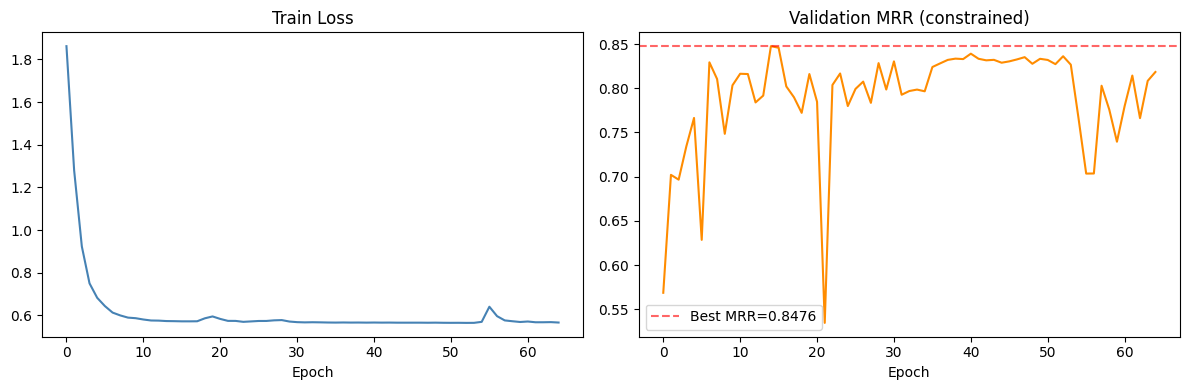

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(train_losses, color='steelblue')
ax1.set_title('Train Loss'); ax1.set_xlabel('Epoch')
ax2.plot(valid_mrrs, color='darkorange')
ax2.axhline(best_mrr, color='red', ls='--', alpha=0.6,
            label=f'Best MRR={best_mrr:.4f}')
ax2.set_title('Validation MRR (constrained)')
ax2.set_xlabel('Epoch'); ax2.legend()
plt.tight_layout()
plt.savefig(f'{LOCAL_DIR}training_curve.pdf', bbox_inches='tight')
plt.show()

## STEP 10. Evaluation — Train / Valid / Test

## 📊 점수 읽는 법 (MRR · Hits)

- **Hits@1** — 정답을 **1등**으로 맞힌 비율 (높을수록 좋음)
- **Hits@3** — 정답이 **상위 3개** 안에 든 비율
- **MRR** — 정답 순위의 역수 평균 (1등=1.0, 2등=0.5, 3등=0.33…) → 전체적인 순위 품질

비교 대상(베이스라인): **랜덤**(찍기) · **빈도**(많이 나온 답) · **DistMult**(단순 그래프 모델). mAb-GATED가 이들을 크게 앞서면 *'문헌의 인과 패턴을 진짜 학습했다'* 는 뜻입니다.
> 원본 논문: 테스트 **Hits@1 84.6%**, 화학 안정성 **99%**. (소규모로 돌리면 수치는 다릅니다)

In [ ]:
def run_evaluation(loader):
    """Run constrained ranking evaluation on a DataLoader."""
    true_ids, pred_rankings = [], []
    model.eval()
    with torch.no_grad():
        for seqs, targets, subcats in loader:
            scores = model(seqs.to(device), edge_index)[:,1:].cpu().numpy()
            for i, (t, sc) in enumerate(zip(targets.tolist(), subcats)):
                true_ids.append(t)
                pred_rankings.append(constrained_ranking(scores[i], sc))
    return evaluate_hits(true_ids, pred_rankings), true_ids, pred_rankings


print('Running evaluation on all splits ...')
tr_m, tr_true, tr_rank = run_evaluation(train_loader)
va_m, va_true, va_rank = run_evaluation(valid_loader)
te_m, te_true, te_rank = run_evaluation(test_loader)

all_m = evaluate_hits(tr_true+va_true+te_true, tr_rank+va_rank+te_rank)

all_results = {
    'Random (constrained)':    random_metrics,
    'Frequency (constrained)': freq_metrics,
    'DistMult (constrained)':  dm_metrics,
    'mAb-GATED (all)':         all_m,
}

print('\n=== Overall Model Comparison ===')
hdr = f'{"Model":35s} {"MRR":>8s} {"H@1":>8s} {"H@3":>8s} {"MR":>8s}'
print(hdr); print('-'*len(hdr))
for name, m in all_results.items():
    print(f'{name:35s} {m["MRR"]:8.4f} {m["Hits@1"]:8.4f} '
          f'{m["Hits@3"]:8.4f} {m["MR"]:8.1f}')

print('\n=== mAb-GATED: Train / Valid / Test ===')
hdr2 = f'{"Split":8s} {"Samples":>10s} {"MRR":>8s} {"H@1":>8s} {"H@3":>8s} {"MR":>8s}'
print(hdr2); print('-'*len(hdr2))
for split_name, split_m, n in [
    ('Train', tr_m, len(train_samples)),
    ('Valid', va_m, len(valid_samples)),
    ('Test',  te_m, len(test_samples)),
]:
    print(f'{split_name:8s} {n:>10,} {split_m["MRR"]:8.4f} '
          f'{split_m["Hits@1"]:8.4f} {split_m["Hits@3"]:8.4f} '
          f'{split_m["MR"]:8.1f}')

print('\n=== mAb-GATED: Performance by Sub-category (Test) ===')
subcat_results = {}
for sc_name in SUBCAT_ORDER:
    sc_idx  = [i for i, s in enumerate(test_samples) if s['subcat'] == sc_name]
    if not sc_idx: continue
    sc_true = [te_true[i] for i in sc_idx]
    sc_rank = [te_rank[i] for i in sc_idx]
    m  = evaluate_hits(sc_true, sc_rank)
    ps = len(subcat_node_ids[sc_name])
    subcat_results[sc_name] = m
    rand_mrr = sum(1/k for k in range(1, ps+1)) / ps if ps else 0
    print(f'  {sc_name:12s}  n={len(sc_idx):5,}, pool={ps:3d}'
          f'  MRR={m["MRR"]:.4f}  H@1={m["Hits@1"]:.4f}'
          f'  H@3={m["Hits@3"]:.4f}  MR={m["MR"]:.1f}'
          f'  (rand MRR={rand_mrr:.3f})')

Running evaluation on all splits ...

=== Overall Model Comparison ===
Model                                    MRR      H@1      H@3       MR
-----------------------------------------------------------------------
Random (constrained)                  0.2770   0.0932   0.2762      6.0
Frequency (constrained)               0.5566   0.3658   0.6646      3.0
DistMult (constrained)                0.5881   0.4090   0.7267      2.8
mAb-GATED (all)                       0.9100   0.8851   0.9005      1.5

=== mAb-GATED: Train / Valid / Test ===
Split       Samples      MRR      H@1      H@3       MR
-------------------------------------------------------
Train         5,740   0.9383   0.9209   0.9209      1.3
Valid         1,230   0.8476   0.8065   0.8553      2.0
Test          1,231   0.8405   0.7969   0.8505      2.0

=== mAb-GATED: Performance by Sub-category (Test) ===
  physical      n=  612, pool= 12  MRR=0.8260  H@1=0.7794  H@3=0.8824  MR=2.3  (rand MRR=0.259)
  chemical      n=  292, 

## STEP 11. Prediction Detail Table

In [ ]:
def make_pred_table(samples, true_ids, pred_rankings, split_name):
    """
    Build a prediction detail table: true node, top-3 predictions,
    rank, and correctness for each sample.
    """
    rows = []
    for s, tid, ranking in zip(samples, true_ids, pred_rankings):
        true_rank = ranking.index(tid) + 1 if tid in ranking else -1
        top3 = [id2node.get(rid, '?') for rid in ranking[:3]]
        rows.append({
            'split':      split_name,
            'subcat':     s['subcat'],
            'true_node':  s['target'],
            'true_rank':  true_rank,
            'correct':    'V' if true_rank == 1 else 'X',
            'pred_1':     top3[0] if len(top3) > 0 else '',
            'pred_2':     top3[1] if len(top3) > 1 else '',
            'pred_3':     top3[2] if len(top3) > 2 else '',
        })
    return pd.DataFrame(rows)


df_tr_pred  = make_pred_table(train_samples, tr_true, tr_rank, 'Train')
df_va_pred  = make_pred_table(valid_samples, va_true, va_rank, 'Valid')
df_te_pred  = make_pred_table(test_samples,  te_true, te_rank, 'Test')
df_all_pred = pd.concat([df_tr_pred, df_va_pred, df_te_pred], ignore_index=True)

pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', 40)

for split_name, df_pred in [('Train', df_tr_pred),
                              ('Valid', df_va_pred),
                              ('Test',  df_te_pred)]:
    correct = df_pred['correct'].eq('V').sum()
    total   = len(df_pred)
    print(f'\n=== {split_name}  '
          f'H@1 = {correct}/{total} = {correct/total*100:.1f}% ===')
    print(df_pred[['subcat','true_node','true_rank',
                   'correct','pred_1','pred_2','pred_3']]
          .sort_values(['subcat','true_node'])
          .to_string(index=False))

df_all_pred.to_csv(f'{LOCAL_DIR}prediction_table1.csv', index=False)
print('\nSaved: prediction_table.csv')

Streaming output truncated to the last 5000 lines.
  physical                     aggregation          1       V          biophysical properties               thermal stability               storage stability
  physical                     aggregation          1       V                 monomer content                       turbidity                      solubility
  physical                     aggregation          1       V                       half-life          biophysical properties        conformational stability
  physical                     aggregation          1       V                self-association                 monomer content              particle formation
  physical                     aggregation          1       V                       viscosity diffusion interaction parameter                      solubility
  physical                     aggregation          1       V                       viscosity diffusion interaction parameter                self-association
 

## STEP 12. Save Outputs

In [ ]:
from google.colab import files as colab_files

torch.save({
    'model_state':       model.state_dict(),
    'config':            CONFIG,
    'node2id':           node2id,  'id2node':      id2node,
    'rel2id':            rel2id,   'id2rel':        id2rel,
    'subcat2id':         subcat2id,'id2subcat':     id2subcat,
    'subcat_node_ids':   dict(subcat_node_ids),
    'CANONICAL_MAP':     CANONICAL_MAP,
    'EXCLUDE_FROM_PREDICTION': list(EXCLUDE_FROM_PREDICTION),
    'CAT_ORDER':         CAT_ORDER,
    'SUBCAT_ORDER':      SUBCAT_ORDER,
    'K':                 K,
    'num_nodes':         num_nodes,
    'num_rels':          num_rels,
    'num_cats':          num_cats,
    'num_dirs':          num_dirs,
    'best_valid_mrr':    best_mrr,
}, f'{LOCAL_DIR}mab_gated.pt')

# Save GAT-refined node embeddings
model.eval()
with torch.no_grad():
    x = model.node_emb.weight[1:]
    for gat, norm in zip(model.gat_list, model.gat_norms):
        x = norm(x + F.elu(gat(x, edge_index)))
pd.DataFrame(x.cpu().numpy(), index=all_nodes_list).to_csv(
    f'{LOCAL_DIR}node_embeddings1.csv')

with open(f'{LOCAL_DIR}results.json', 'w') as f:
    json.dump({
        'overall_metrics': all_results,
        'split_metrics':   {'train': tr_m, 'valid': va_m, 'test': te_m},
        'subcat_metrics':  subcat_results,
        'dataset_info': {
            'min_freq':          CONFIG['min_freq'],
            'n_train_samples':   len(train_samples),
            'n_valid_samples':   len(valid_samples),
            'n_test_samples':    len(test_samples),
            'n_unique_nodes':    num_nodes,
            'subcat_pool_sizes': {sc: len(ids)
                                  for sc, ids in subcat_node_ids.items()},
        },
    }, f, indent=2)

print('Copying to Google Drive ...')
for fname in ['mab_gated.pt', 'node_embeddings.csv', 'results.json',
              'training_curve.pdf', 'prediction_table.csv']:
    src = f'{LOCAL_DIR}{fname}'
    if os.path.exists(src):
        try:
            shutil.copy(src, f'{RESULT_DIR}{fname}')
            print(f'  OK  : {fname}')
        except OSError:
            print(f'  FAIL: {fname} — downloading ...')
            colab_files.download(src)

print('\n=== Pipeline Complete ===')

Copying to Google Drive ...
  OK  : mab_gated.pt
  OK  : results.json
  OK  : training_curve.pdf

=== Pipeline Complete ===
